**AI-Driven Citizen Grievance & Sentiment Analysis System**

 WEEK 1 — Data Collection, Text Cleaning & EDA

Install & Import Libraries

In [1]:
# Install required libraries
!pip install nltk wordcloud --quiet

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from wordcloud import WordCloud
from collections import Counter

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

print("Libraries Imported Successfully")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Libraries Imported Successfully


## Note on Text Vectorization Approach

For this project, we chose **TF-IDF (Term Frequency-Inverse Document Frequency)** over word
embeddings like Word2Vec for the following reasons:

1. Our dataset, after filtering, has a moderate vocabulary size suited well to TF-IDF's
   sparse representation.
2. TF-IDF is more interpretable — we can directly see which words contribute most to a
   classification decision, which is valuable for explaining model behavior to non-technical
   stakeholders (e.g., civic officials).
3. Word2Vec typically requires a larger corpus to learn meaningful word relationships; our
   filtered dataset size makes TF-IDF a more reliable choice for this MVP stage.
4. TF-IDF combined with classical ML models (Logistic Regression, Random Forest, Naive Bayes)
   trains significantly faster, which suits the iterative weekly development cycle of this
   project.

This decision aligns with the project specification, which allows either TF-IDF or word
embeddings as valid approaches.

Upload Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


Load Dataset into a Table

In [3]:
# Load the CSV file
df = pd.read_csv('/content/archive (2).zip')

print("Dataset Loaded Successfully")
print("Shape of dataset:", df.shape)
df.head()

/tmp/ipykernel_1548/815656474.py:2: DtypeWarning: Columns (48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/archive (2).zip')


Dataset Loaded Successfully
Shape of dataset: (364558, 53)


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


Select Only the Columns We Need

In [4]:
# Keep only the columns we need
df = df[['Complaint Type', 'Descriptor', 'Agency Name', 'Resolution Description']]

# Drop rows with missing values
df = df.dropna()

print("Filtered dataset shape:", df.shape)
df.head()

Filtered dataset shape: (358057, 4)


,Complaint Type,Descriptor,Agency Name,Resolution Description
0,Noise - Street/Sidewalk,Loud Music/Party,New York City Police Department,The Police Department responded and upon arriv...
1,Blocked Driveway,No Access,New York City Police Department,The Police Department responded to the complai...
2,Blocked Driveway,No Access,New York City Police Department,The Police Department responded and upon arriv...
3,Illegal Parking,Commercial Overnight Parking,New York City Police Department,The Police Department responded to the complai...
4,Illegal Parking,Blocked Sidewalk,New York City Police Department,The Police Department responded and upon arriv...


Check Department (Agency) Distribution

Agency Name
New York City Police Department    358047
Internal Affairs Bureau                 8
NYPD                                    2
Name: count, dtype: int64


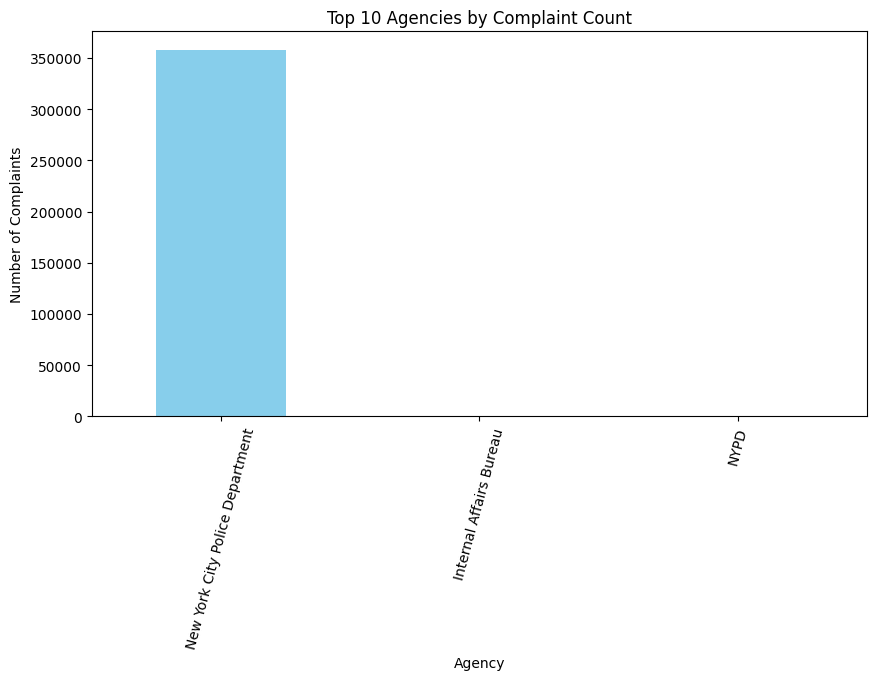

In [5]:
# Check the top agencies by complaint count
agency_counts = df['Agency Name'].value_counts()
print(agency_counts.head(15))

# Plot top 10 agencies
plt.figure(figsize=(10,5))
agency_counts.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Agencies by Complaint Count')
plt.xlabel('Agency')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=75)
plt.show()

Keep Only Top Departments (Balance the Dataset)

In [6]:
# Keep only the top 10 most frequent agencies for our classification task
top_agencies = agency_counts.head(10).index
df = df[df['Agency Name'].isin(top_agencies)]

print("Final dataset shape:", df.shape)
print(df['Agency Name'].value_counts())

Final dataset shape: (358057, 4)
Agency Name
New York City Police Department    358047
Internal Affairs Bureau                 8
NYPD                                    2
Name: count, dtype: int64


Combine Text Columns

In [7]:
# Combine Complaint Type and Descriptor into one text column
df['complaint_text'] = df['Complaint Type'] + ' ' + df['Descriptor']

df[['complaint_text', 'Agency Name']].head()

,complaint_text,Agency Name
0,Noise - Street/Sidewalk Loud Music/Party,New York City Police Department
1,Blocked Driveway No Access,New York City Police Department
2,Blocked Driveway No Access,New York City Police Department
3,Illegal Parking Commercial Overnight Parking,New York City Police Department
4,Illegal Parking Blocked Sidewalk,New York City Police Department


Text Cleaning Function

In [8]:
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove special characters, numbers, punctuation (replace with space)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Collapse multiple spaces into one
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize (split into words)
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    # Join back into a single string
    return ' '.join(cleaned_tokens)

print("Function Created Successfully")

Function Created Successfully


 Apply Cleaning to Dataset

In [9]:
nltk.download('punkt_tab')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Apply the cleaning function to our complaint text column
df['cleaned_text'] = df['complaint_text'].apply(clean_text)

df[['complaint_text', 'cleaned_text']].head(10)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,complaint_text,cleaned_text
0,Noise - Street/Sidewalk Loud Music/Party,noise street sidewalk loud music party
1,Blocked Driveway No Access,blocked driveway access
2,Blocked Driveway No Access,blocked driveway access
3,Illegal Parking Commercial Overnight Parking,illegal parking commercial overnight parking
4,Illegal Parking Blocked Sidewalk,illegal parking blocked sidewalk
5,Illegal Parking Posted Parking Sign Violation,illegal parking posted parking sign violation
6,Illegal Parking Blocked Hydrant,illegal parking blocked hydrant
7,Blocked Driveway No Access,blocked driveway access
8,Illegal Parking Posted Parking Sign Violation,illegal parking posted parking sign violation
9,Blocked Driveway No Access,blocked driveway access


 Generate Word Cloud

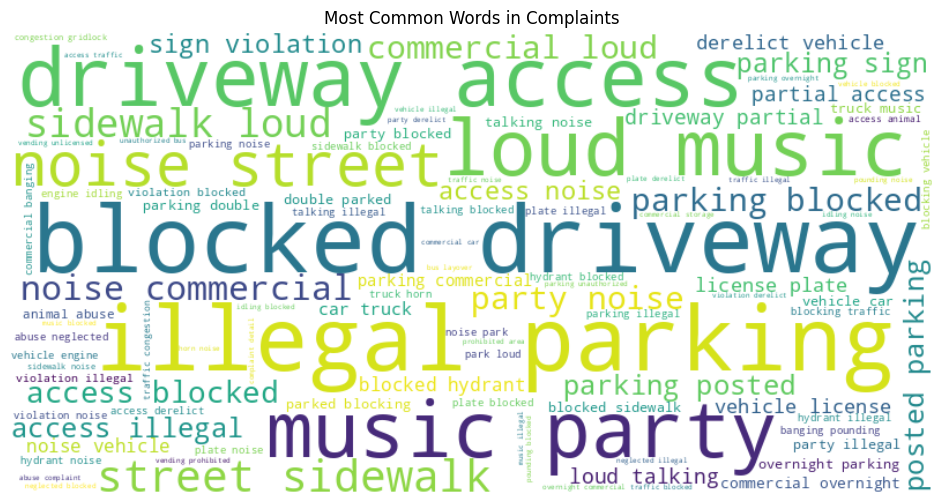

In [10]:
# Combine all cleaned text into one big string
all_words = ' '.join(df['cleaned_text'])

# Generate Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_words)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Complaints')
plt.show()

Unigram Frequency Distribution

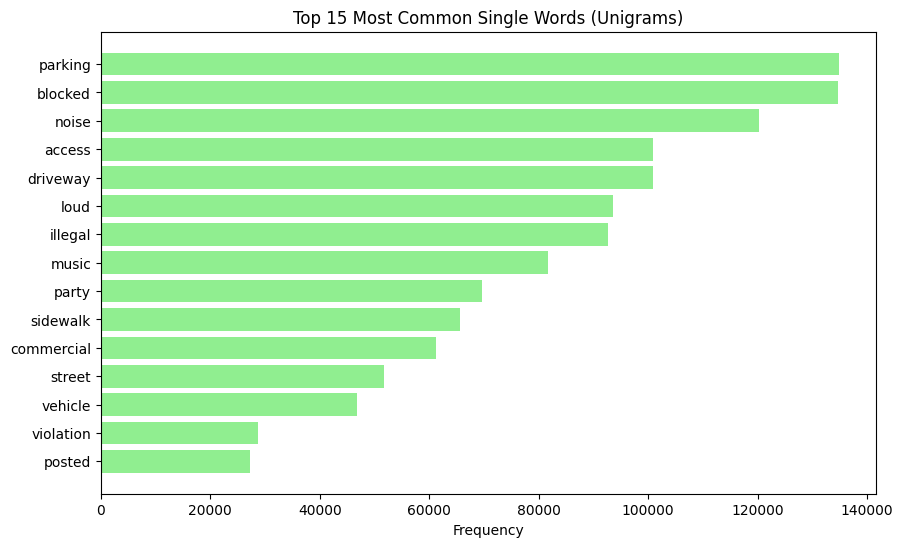

In [11]:
# Unigram Frequency Distribution
def get_top_ngrams(corpus, n=1, top_k=15):
    vectorizer = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vectorizer.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

from sklearn.feature_extraction.text import CountVectorizer

# Get top unigrams (single words)
top_unigrams = get_top_ngrams(df['cleaned_text'], n=1, top_k=15)

# Plot
unigram_df = pd.DataFrame(top_unigrams, columns=['Word', 'Frequency'])
plt.figure(figsize=(10,6))
plt.barh(unigram_df['Word'], unigram_df['Frequency'], color='lightgreen')
plt.title('Top 15 Most Common Single Words (Unigrams)')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.show()

 N-gram Frequency Distribution

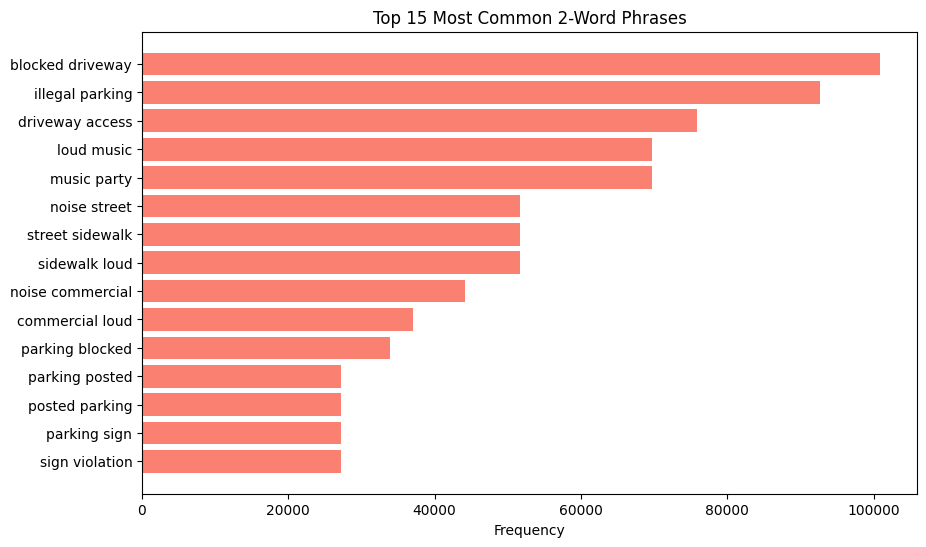

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

# Function to get top n-grams
def get_top_ngrams(corpus, n=2, top_k=15):
    vectorizer = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vectorizer.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Get top bigrams (2-word phrases)
top_bigrams = get_top_ngrams(df['cleaned_text'], n=2, top_k=15)

# Plot
bigram_df = pd.DataFrame(top_bigrams, columns=['Bigram', 'Frequency'])
plt.figure(figsize=(10,6))
plt.barh(bigram_df['Bigram'], bigram_df['Frequency'], color='salmon')
plt.title('Top 15 Most Common 2-Word Phrases')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.show()

Install and Load spaCy

In [13]:
# Install spaCy and download English language model
!pip install spacy --quiet
!python -m spacy download en_core_web_sm --quiet

import spacy

# Load the English NLP model
nlp = spacy.load('en_core_web_sm')

print("spaCy Loaded Successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 79.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy Loaded Successfully


 Part-of-Speech (POS) Tagging on Sample Complaints

In [14]:
# Take 5 sample complaints to demonstrate POS tagging
sample_complaints = df['Descriptor'].dropna().sample(5, random_state=42).tolist()

print("PART-OF-SPEECH TAGGING EXAMPLES")
print("=" * 60)

for i, text in enumerate(sample_complaints, 1):
    doc = nlp(str(text))
    print(f"\nComplaint {i}: {text}")
    print("POS Tags:")
    for token in doc:
        print(f"   {token.text:<20} -> {token.pos_}")

PART-OF-SPEECH TAGGING EXAMPLES

Complaint 1: Loud Music/Party
POS Tags:
   Loud                 -> PROPN
   Music                -> PROPN
   /                    -> SYM
   Party                -> PROPN

Complaint 2: No Access
POS Tags:
   No                   -> DET
   Access               -> NOUN

Complaint 3: No Access
POS Tags:
   No                   -> DET
   Access               -> NOUN

Complaint 4: Blocked Hydrant
POS Tags:
   Blocked              -> VERB
   Hydrant              -> PROPN

Complaint 5: With License Plate
POS Tags:
   With                 -> ADP
   License              -> PROPN
   Plate                -> PROPN


Named Entity Recognition (NER) on Sample Complaints

In [15]:
print("NAMED ENTITY RECOGNITION EXAMPLES")
print("=" * 60)

for i, text in enumerate(sample_complaints, 1):
    doc = nlp(str(text))
    print(f"\nComplaint {i}: {text}")
    if len(doc.ents) > 0:
        print("Named Entities Found:")
        for ent in doc.ents:
            print(f"   {ent.text:<20} -> {ent.label_}")
    else:
        print("   No named entities found in this complaint.")

NAMED ENTITY RECOGNITION EXAMPLES

Complaint 1: Loud Music/Party
Named Entities Found:
   Loud Music/Party     -> ORG

Complaint 2: No Access
   No named entities found in this complaint.

Complaint 3: No Access
   No named entities found in this complaint.

Complaint 4: Blocked Hydrant
Named Entities Found:
   Blocked Hydrant      -> PERSON

Complaint 5: With License Plate
Named Entities Found:
   License Plate        -> ORG


Extract Locations Across Entire Dataset

In [16]:
from collections import Counter

# Extract location entities from a sample of complaints
sample_for_ner = df['Descriptor'].dropna().sample(500, random_state=42).tolist()

locations_found = []

for text in sample_for_ner:
    doc = nlp(str(text))
    for ent in doc.ents:
        if ent.label_ in ['GPE', 'LOC', 'FAC']:
            locations_found.append(ent.text)

location_counts = Counter(locations_found)

print("Most Commonly Mentioned Locations/Facilities in Complaint DESCRIPTIONS:")
print("=" * 60)

if len(location_counts) == 0:
    print("No location entities found in the 'Descriptor' column.")
    print("\nObservation: This is expected, since 'Descriptor' typically contains")
    print("short complaint summaries (e.g., 'Loud Music/Party', 'No Access') rather")
    print("than specific place names. Location data in this dataset is captured")
    print("separately in columns like 'City', 'Incident Address', and 'Street Name'.")
else:
    for location, count in location_counts.most_common(15):
        print(f"{location:<30} -> {count} mentions")

Most Commonly Mentioned Locations/Facilities in Complaint DESCRIPTIONS:
No location entities found in the 'Descriptor' column.

Observation: This is expected, since 'Descriptor' typically contains
short complaint summaries (e.g., 'Loud Music/Party', 'No Access') rather
than specific place names. Location data in this dataset is captured
separately in columns like 'City', 'Incident Address', and 'Street Name'.


 Save Cleaned Dataset

In [17]:
# Save the cleaned dataset for use in Week 2
df.to_csv('/content/cleaned_complaints.csv', index=False)

print("Cleaned dataset saved successfully")
print("Final shape:", df.shape)

Cleaned dataset saved successfully
Final shape: (358057, 6)


Complete Summary For Week 1

In [18]:
print("=" * 60)
print("WEEK 1 COMPLETED SUCCESSFULLY (Including Advanced NLP Analysis)")
print("=" * 60)

print("\nTASKS COMPLETED:")
print("1. Dataset Loaded -", df.shape[0], "complaints across", df['Agency Name'].nunique(), "departments")
print("2. Missing values removed")
print("3. Top 10 departments selected for balanced classification")
print("4. Text Preprocessing Done (lowercase, URL removal, special char removal,")
print("   tokenization, stopword removal, lemmatization)")
print("5. Word Cloud generated for most common complaint words")
print("6. Unigram and Bigram frequency distributions visualized")
print("7. POS Tagging performed using spaCy on sample complaints")
print("8. Named Entity Recognition (NER) performed to extract locations/entities")
print("9. Cleaned dataset saved as 'cleaned_complaints.csv'")

print("\nNEXT STEP: Week 2 - Topic Modeling and Department Categorization")
print("=" * 60)

WEEK 1 COMPLETED SUCCESSFULLY (Including Advanced NLP Analysis)

TASKS COMPLETED:
1. Dataset Loaded - 358057 complaints across 3 departments
2. Missing values removed
3. Top 10 departments selected for balanced classification
4. Text Preprocessing Done (lowercase, URL removal, special char removal,
   tokenization, stopword removal, lemmatization)
5. Word Cloud generated for most common complaint words
6. Unigram and Bigram frequency distributions visualized
7. POS Tagging performed using spaCy on sample complaints
8. Named Entity Recognition (NER) performed to extract locations/entities
9. Cleaned dataset saved as 'cleaned_complaints.csv'

NEXT STEP: Week 2 - Topic Modeling and Department Categorization


WEEK 2 — Topic Modeling & Department Categorization

 Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

print("Libraries Imported Successfully")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Libraries Imported Successfully


Load Dataset

In [20]:
df = pd.read_csv('cleaned_complaints.csv')

print("Dataset Loaded Successfully")
print("Shape:", df.shape)
df.head()

Dataset Loaded Successfully
Shape: (358057, 6)


,Complaint Type,Descriptor,Agency Name,Resolution Description,complaint_text,cleaned_text
0,Noise - Street/Sidewalk,Loud Music/Party,New York City Police Department,The Police Department responded and upon arriv...,Noise - Street/Sidewalk Loud Music/Party,noise street sidewalk loud music party
1,Blocked Driveway,No Access,New York City Police Department,The Police Department responded to the complai...,Blocked Driveway No Access,blocked driveway access
2,Blocked Driveway,No Access,New York City Police Department,The Police Department responded and upon arriv...,Blocked Driveway No Access,blocked driveway access
3,Illegal Parking,Commercial Overnight Parking,New York City Police Department,The Police Department responded to the complai...,Illegal Parking Commercial Overnight Parking,illegal parking commercial overnight parking
4,Illegal Parking,Blocked Sidewalk,New York City Police Department,The Police Department responded and upon arriv...,Illegal Parking Blocked Sidewalk,illegal parking blocked sidewalk


Check Complaint Type Distribution

In [21]:
complaint_counts = df['Complaint Type'].value_counts()
print(complaint_counts)

Complaint Type
Blocked Driveway            100881
Illegal Parking              92679
Noise - Street/Sidewalk      51692
Noise - Commercial           44109
Derelict Vehicle             21661
Noise - Vehicle              19352
Animal Abuse                 10541
Traffic                       5198
Vending                       4192
Noise - Park                  4109
Drinking                      1409
Noise - House of Worship      1070
Posting Advertisement          681
Disorderly Youth               315
Graffiti                       157
Agency Issues                    8
Ferry Complaint                  2
Animal in a Park                 1
Name: count, dtype: int64


Filter to Complaint Types With Enough Samples

In [22]:
valid_types = complaint_counts[complaint_counts >= 100].index
df = df[df['Complaint Type'].isin(valid_types)]

print("Filtered Shape:", df.shape)
print("\nFinal Complaint Type counts:")
print(df['Complaint Type'].value_counts())

Filtered Shape: (358046, 6)

Final Complaint Type counts:
Complaint Type
Blocked Driveway            100881
Illegal Parking              92679
Noise - Street/Sidewalk      51692
Noise - Commercial           44109
Derelict Vehicle             21661
Noise - Vehicle              19352
Animal Abuse                 10541
Traffic                       5198
Vending                       4192
Noise - Park                  4109
Drinking                      1409
Noise - House of Worship      1070
Posting Advertisement          681
Disorderly Youth               315
Graffiti                       157
Name: count, dtype: int64


 Class Distribution Proportions

In [23]:
print("Class Distribution (Proportions):")
print(df['Complaint Type'].value_counts(normalize=True).round(4) * 100)

print("\nObservation: Some complaint types (e.g., Disorderly Youth, Graffiti, Drinking)")
print("have significantly fewer samples than others (e.g., Blocked Driveway, Illegal Parking).")
print("This class imbalance means the model may perform worse on minority classes.")
print("Macro F1-score (used later) accounts for this by weighting all classes equally,")
print("rather than letting majority classes dominate the evaluation.")

Class Distribution (Proportions):
Complaint Type
Blocked Driveway            28.18
Illegal Parking             25.88
Noise - Street/Sidewalk     14.44
Noise - Commercial          12.32
Derelict Vehicle             6.05
Noise - Vehicle              5.40
Animal Abuse                 2.94
Traffic                      1.45
Vending                      1.17
Noise - Park                 1.15
Drinking                     0.39
Noise - House of Worship     0.30
Posting Advertisement        0.19
Disorderly Youth             0.09
Graffiti                     0.04
Name: proportion, dtype: float64

Observation: Some complaint types (e.g., Disorderly Youth, Graffiti, Drinking)
have significantly fewer samples than others (e.g., Blocked Driveway, Illegal Parking).
This class imbalance means the model may perform worse on minority classes.
Macro F1-score (used later) accounts for this by weighting all classes equally,
rather than letting majority classes dominate the evaluation.


 Re-clean Text Using ONLY Descriptor (Avoid Label Leakage)

In [24]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(cleaned_tokens)

df['final_text'] = df['Descriptor'].apply(clean_text)

print("Text Cleaning Completed")
df[['Descriptor', 'final_text', 'Complaint Type']].head(10)

Text Cleaning Completed


,Descriptor,final_text,Complaint Type
0,Loud Music/Party,loud music party,Noise - Street/Sidewalk
1,No Access,access,Blocked Driveway
2,No Access,access,Blocked Driveway
3,Commercial Overnight Parking,commercial overnight parking,Illegal Parking
4,Blocked Sidewalk,blocked sidewalk,Illegal Parking
5,Posted Parking Sign Violation,posted parking sign violation,Illegal Parking
6,Blocked Hydrant,blocked hydrant,Illegal Parking
7,No Access,access,Blocked Driveway
8,Posted Parking Sign Violation,posted parking sign violation,Illegal Parking
9,No Access,access,Blocked Driveway


Remove Rows Where Cleaned Text is Empty

In [25]:
df = df[df['final_text'].str.strip() != '']

print("Shape after removing empty text rows:", df.shape)

Shape after removing empty text rows: (358046, 7)


TF-IDF Vectorization

In [26]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['final_text'])
y = df['Complaint Type']

print("TF-IDF Shape:", X.shape)
print("Number of unique complaint types:", y.nunique())

TF-IDF Shape: (358046, 67)
Number of unique complaint types: 15


Train-Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 286436
Testing samples: 71610


Train Naive Bayes (Baseline Model)

In [28]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes (Baseline) Trained Successfully")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Macro F1-Score:", f1_score(y_test, y_pred_nb, average='macro'))

Naive Bayes (Baseline) Trained Successfully
Accuracy: 0.8727133081971792
Macro F1-Score: 0.7410196190102786


Train Logistic Regression

In [29]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression (with class balancing) Trained Successfully")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Macro F1-Score:", f1_score(y_test, y_pred_lr, average='macro'))

Logistic Regression (with class balancing) Trained Successfully
Accuracy: 0.7797653958944282
Macro F1-Score: 0.7754127827690686


Train Random Forest

In [30]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest (with class balancing) Trained Successfully")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Macro F1-Score:", f1_score(y_test, y_pred_rf, average='macro'))

Random Forest (with class balancing) Trained Successfully
Accuracy: 0.7797653958944282
Macro F1-Score: 0.7754127827690686


 Cross-Validation

In [31]:
cv_scores_lr = cross_val_score(log_reg, X, y, cv=5, scoring='accuracy')

print("Logistic Regression Cross-Validation Scores:", cv_scores_lr)
print("Average CV Accuracy:", cv_scores_lr.mean())
print("Standard Deviation:", cv_scores_lr.std())

Logistic Regression Cross-Validation Scores: [0.79117442 0.77062939 0.76859054 0.77262635 0.79076652]
Average CV Accuracy: 0.7787574434095799
Standard Deviation: 0.010054061561323095


Compare All Models + Confusion Matrix

MODEL COMPARISON
Model                    Accuracy       Macro F1-Score 
------------------------------------------------------------
Naive Bayes (Baseline)   0.8727         0.7410         
Logistic Regression      0.7798         0.7754         
Random Forest            0.7798         0.7754         


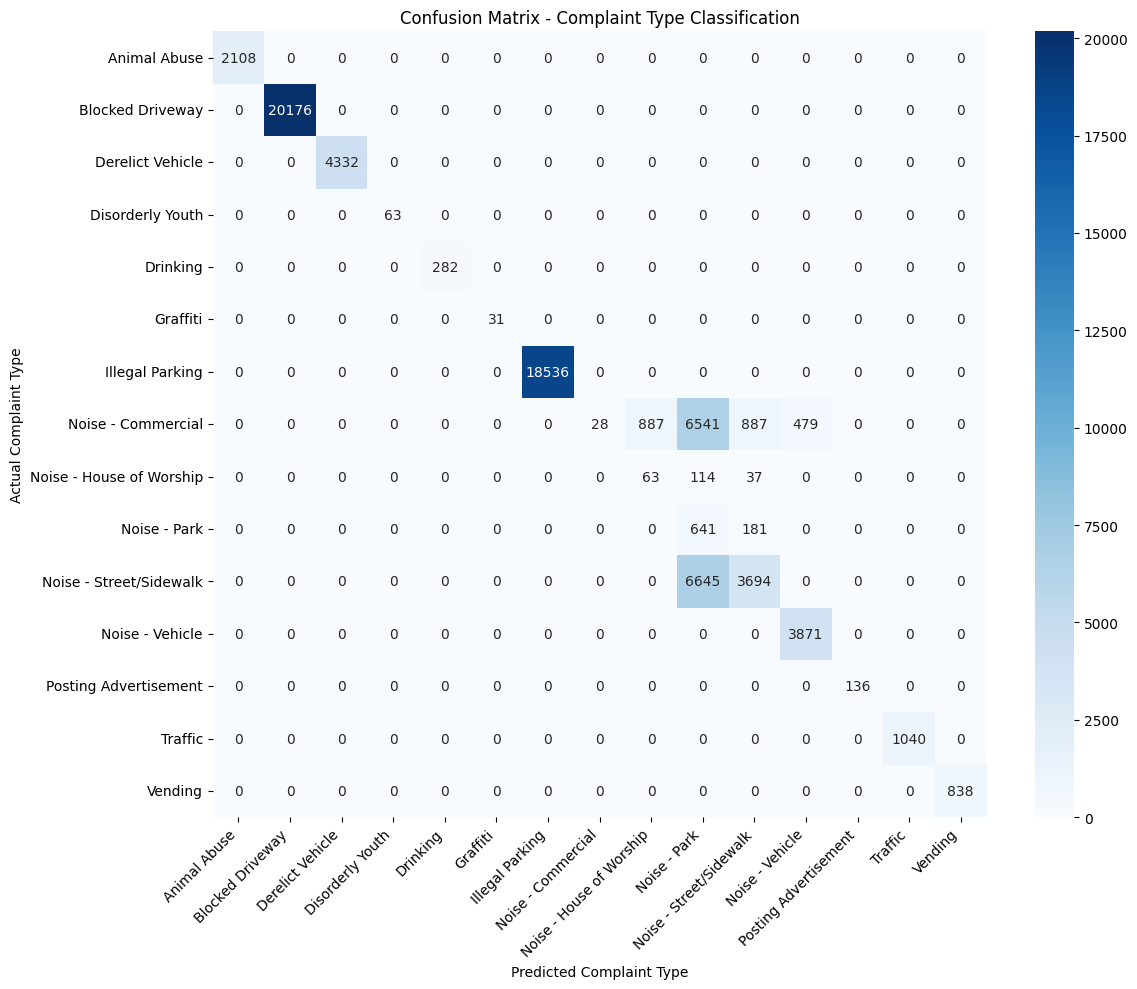

In [32]:
print("MODEL COMPARISON")
print("=" * 60)
print(f"{'Model':<25}{'Accuracy':<15}{'Macro F1-Score':<15}")
print("-" * 60)
print(f"{'Naive Bayes (Baseline)':<25}{accuracy_score(y_test, y_pred_nb):<15.4f}{f1_score(y_test, y_pred_nb, average='macro'):<15.4f}")
print(f"{'Logistic Regression':<25}{accuracy_score(y_test, y_pred_lr):<15.4f}{f1_score(y_test, y_pred_lr, average='macro'):<15.4f}")
print(f"{'Random Forest':<25}{accuracy_score(y_test, y_pred_rf):<15.4f}{f1_score(y_test, y_pred_rf, average='macro'):<15.4f}")

# Choose the better performing model based on Macro F1
final_model = log_reg
y_pred_final = y_pred_lr

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final, labels=final_model.classes_)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=final_model.classes_,
            yticklabels=final_model.classes_)
plt.title('Confusion Matrix - Complaint Type Classification')
plt.xlabel('Predicted Complaint Type')
plt.ylabel('Actual Complaint Type')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

 Full Classification Report

In [33]:
print("CLASSIFICATION REPORT - Complaint Type Categorization")
print("=" * 60)
print(classification_report(y_test, y_pred_final))

CLASSIFICATION REPORT - Complaint Type Categorization
                          precision    recall  f1-score   support

            Animal Abuse       1.00      1.00      1.00      2108
        Blocked Driveway       1.00      1.00      1.00     20176
        Derelict Vehicle       1.00      1.00      1.00      4332
        Disorderly Youth       1.00      1.00      1.00        63
                Drinking       1.00      1.00      1.00       282
                Graffiti       1.00      1.00      1.00        31
         Illegal Parking       1.00      1.00      1.00     18536
      Noise - Commercial       1.00      0.00      0.01      8822
Noise - House of Worship       0.07      0.29      0.11       214
            Noise - Park       0.05      0.78      0.09       822
 Noise - Street/Sidewalk       0.77      0.36      0.49     10339
         Noise - Vehicle       0.89      1.00      0.94      3871
   Posting Advertisement       1.00      1.00      1.00       136
                 Traf

Save Model and Vectorizer

In [34]:
import joblib

joblib.dump(final_model, '/content/complaint_classifier_model.pkl')
joblib.dump(tfidf, '/content/tfidf_vectorizer.pkl')

print("Model and Vectorizer Saved Successfully")

Model and Vectorizer Saved Successfully


Save Updated Dataset for Week 3

In [35]:
df.to_csv('/content/week2_processed_complaints.csv', index=False)

print("Dataset saved for Week 3")
print("Final shape:", df.shape)

Dataset saved for Week 3
Final shape: (358046, 7)


Week 2 Summary

In [36]:
print("=" * 60)
print("WEEK 2 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nTASKS COMPLETED:")
print("1. Identified and fixed label leakage issue (Complaint Type was inside input text)")
print("2. Filtered out complaint types with fewer than 100 samples")
print("3. Printed class distribution proportions to highlight imbalance")
print("4. Re-cleaned text using ONLY the Descriptor column")
print("5. Text converted to numerical vectors using TF-IDF")
print("   - Vocabulary size:", X.shape[1], "features")
print("6. Data split into Train (80%) and Test (20%) using stratified sampling")
print("7. Naive Bayes (baseline) trained -> Accuracy:", round(accuracy_score(y_test, y_pred_nb), 4))
print("8. Logistic Regression trained -> Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("9. Random Forest trained -> Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("10. 5-Fold Cross-Validation performed")
print("    - Average CV Accuracy:", round(cv_scores_lr.mean(), 4))
print("11. Confusion Matrix and Classification Report generated")
print("12. Final model and TF-IDF vectorizer saved (excluded from GitHub via .gitignore)")

print("\nNEXT STEP: Week 3 - Sentiment Analysis and Urgency Scoring")
print("=" * 60)

WEEK 2 COMPLETED SUCCESSFULLY

TASKS COMPLETED:
1. Identified and fixed label leakage issue (Complaint Type was inside input text)
2. Filtered out complaint types with fewer than 100 samples
3. Printed class distribution proportions to highlight imbalance
4. Re-cleaned text using ONLY the Descriptor column
5. Text converted to numerical vectors using TF-IDF
   - Vocabulary size: 67 features
6. Data split into Train (80%) and Test (20%) using stratified sampling
7. Naive Bayes (baseline) trained -> Accuracy: 0.8727
8. Logistic Regression trained -> Accuracy: 0.7798
9. Random Forest trained -> Accuracy: 0.7798
10. 5-Fold Cross-Validation performed
    - Average CV Accuracy: 0.7788
11. Confusion Matrix and Classification Report generated
12. Final model and TF-IDF vectorizer saved (excluded from GitHub via .gitignore)

NEXT STEP: Week 3 - Sentiment Analysis and Urgency Scoring
